In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Magnetic field of a finite straight wire above the plane

We simulate the magnetic field produced by a finite current-carrying wire using the Biot–Savart law.

The wire is:
- parallel to the **y-axis**
- lifted by **10 µm** above the **xy-plane**
- carrying a current of **2 mA**

## Geometry
- Observation region: square in the xy-plane
- Size: **200 µm × 200 µm**
- Grid spacing: **5 µm**
- Wire runs from the left side of the square to the right side
- Thus the wire extends along **x**, while **z** is perpendicular to the plane

## Biot–Savart law
\[
d\mathbf{B}=\frac{\mu_0 I}{4\pi}\frac{d\boldsymbol{\ell}\times\mathbf{r}}{|\mathbf{r}|^3}
\]

where:
- \(\mu_0\) is vacuum permeability
- \(I\) is current
- \(d\boldsymbol{\ell}\) is a wire element
- \(\mathbf{r}\) points from the wire element to the observation point

The total field is obtained by summing the contributions from all short wire segments.

In [14]:
mu0 = 4 * np.pi * 1e-7   # [T m / A]
I = 2e-3                 # 2 mA

# Scan region
L_um = 200
step_um = 5

x_um = np.arange(-L_um/2, L_um/2 + step_um, step_um)
y_um = np.arange(-L_um/2, L_um/2 + step_um, step_um)

x = x_um * 1e-6
y = y_um * 1e-6

X, Y = np.meshgrid(x, y)
Z = np.zeros_like(X)

# Wire height
z_wire = 10e-6

# Correct wire orientation: parallel to x-axis
r1 = np.array([-100e-6, 0.0, z_wire])
r2 = np.array([ 100e-6, 0.0, z_wire])

print("Grid shape:", X.shape)
print("x range [um]:", x_um[0], "to", x_um[-1])
print("y range [um]:", y_um[0], "to", y_um[-1])
print("Wire start [um]:", r1 * 1e6)
print("Wire end   [um]:", r2 * 1e6)
print("Wire length [um]:", np.linalg.norm(r2-r1) * 1e6)
print("Wire height above plane [um]:", z_wire * 1e6)
print("Current [mA]:", I * 1e3)

Grid shape: (41, 41)
x range [um]: -100.0 to 100.0
y range [um]: -100.0 to 100.0
Wire start [um]: [-100.    0.   10.]
Wire end   [um]: [100.   0.  10.]
Wire length [um]: 200.0
Wire height above plane [um]: 10.0
Current [mA]: 2.0


In [15]:
#masacer the wire into 
Nseg = 1000
t = np.linspace(0, 1, Nseg + 1)

wire_points = r1[None, :] + (r2 - r1)[None, :] * t[:, None]
seg_mid = 0.5 * (wire_points[:-1] + wire_points[1:])
dl = wire_points[1:] - wire_points[:-1]

print("Number of wire segments:", Nseg)
print("Segment length [um]:", np.linalg.norm(dl[0]) * 1e6)
print("First midpoint [um]:", seg_mid[0] * 1e6)
print("Last midpoint  [um]:", seg_mid[-1] * 1e6)

Number of wire segments: 1000
Segment length [um]: 0.20000000000000487
First midpoint [um]: [-99.9   0.   10. ]
Last midpoint  [um]: [99.9  0.  10. ]


In [16]:
# Compute magnetic field using Biot-Savart law
Bx = np.zeros_like(X, dtype=float)
By = np.zeros_like(X, dtype=float)
Bz = np.zeros_like(X, dtype=float)

for i in range(Nseg):
    rx = X - seg_mid[i, 0]
    ry = Y - seg_mid[i, 1]
    rz = Z - seg_mid[i, 2]

    r_mag = np.sqrt(rx**2 + ry**2 + rz**2)
    r_mag = np.where(r_mag < 1e-15, 1e-15, r_mag)

    dlx, dly, dlz = dl[i]

    cx = dly * rz - dlz * ry
    cy = dlz * rx - dlx * rz
    cz = dlx * ry - dly * rx

    prefactor = mu0 * I / (4 * np.pi * r_mag**3)

    Bx += prefactor * cx
    By += prefactor * cy
    Bz += prefactor * cz

Bmag = np.sqrt(Bx**2 + By**2 + Bz**2)

print("Max |B| [T]:", np.max(Bmag))
print("Max |B| [uT]:", np.max(Bmag) * 1e6)
print("Max |Bx| [uT]:", np.max(np.abs(Bx)) * 1e6)
print("Max |By| [uT]:", np.max(np.abs(By)) * 1e6)
print("Max |Bz| [uT]:", np.max(np.abs(Bz)) * 1e6)
print("Center point field [uT]:", Bmag[len(y_um)//2, len(x_um)//2] * 1e6)

Max |B| [T]: 3.9801487803485424e-05
Max |B| [uT]: 39.80148780348542
Max |Bx| [uT]: 0.0
Max |By| [uT]: 39.80148780348542
Max |Bz| [uT]: 19.80295104987284
Center point field [uT]: 39.80148780348542


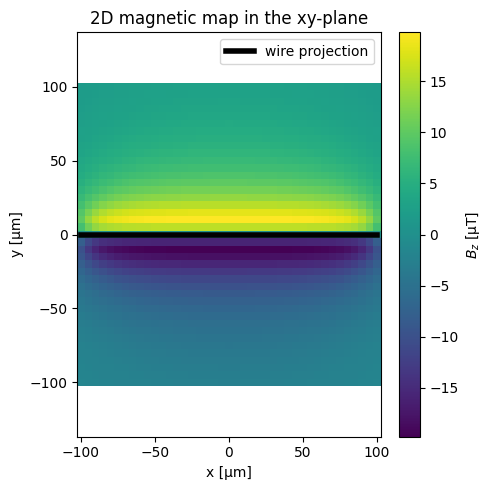

Displayed quantity: Bz
Bz min [uT]: -19.80295104987284
Bz max [uT]: 19.80295104987284
Wire projection: from x = -100.0 um to 100.0 um at y = 0.0 um


In [17]:
plt.figure(figsize=(5, 5))
plt.pcolormesh(X * 1e6, Y * 1e6, Bz * 1e6, shading='auto')
plt.colorbar(label='$B_z$ [µT]')

plt.plot([r1[0]*1e6, r2[0]*1e6],
         [r1[1]*1e6, r2[1]*1e6],
         'k-', lw=4, label='wire projection')

plt.xlabel('x [µm]')
plt.ylabel('y [µm]')
plt.title('2D magnetic map in the xy-plane')
plt.legend()
plt.axis('equal')
plt.tight_layout()
plt.show()

print("Displayed quantity: Bz")
print("Bz min [uT]:", np.min(Bz) * 1e6)
print("Bz max [uT]:", np.max(Bz) * 1e6)
print("Wire projection: from x =", r1[0]*1e6, "um to", r2[0]*1e6, "um at y =", r1[1]*1e6, "um")

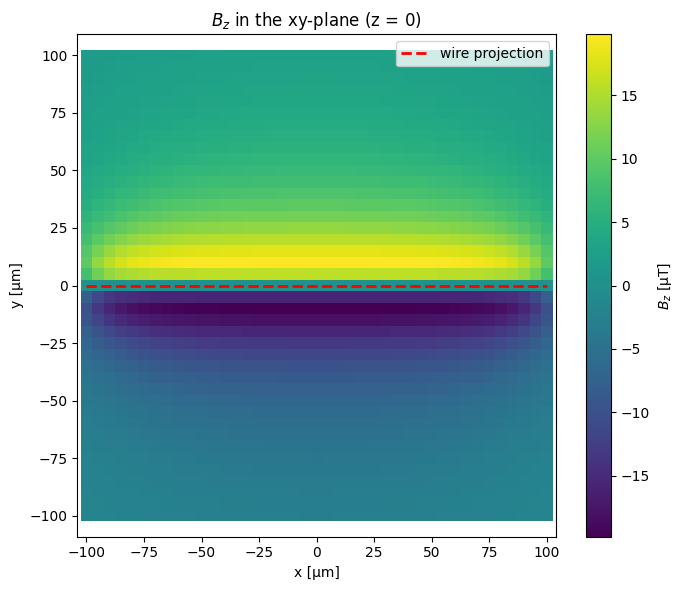

In [18]:
plt.figure(figsize=(7, 6))
plt.pcolormesh(X * 1e6, Y * 1e6, Bz * 1e6, shading='auto')
plt.colorbar(label='$B_z$ [µT]')
plt.xlabel('x [µm]')
plt.ylabel('y [µm]')
plt.title('$B_z$ in the xy-plane (z = 0)')

plt.plot([r1[0]*1e6, r2[0]*1e6], [r1[1]*1e6, r2[1]*1e6], 'r--', lw=2, label='wire projection')
plt.legend()
plt.axis('equal')
plt.tight_layout()
plt.show()

In [21]:
signal_map = Bz * 1e9   # in nT

print("Signal map chosen: Bz")
print("Signal units: nT")
print("Signal min [nT]:", np.min(signal_map))
print("Signal max [nT]:", np.max(signal_map))

Signal map chosen: Bz
Signal units: nT
Signal min [nT]: -6137.165706054618
Signal max [nT]: 6137.165706054618


In [22]:
t_ms = np.linspace(0, 90, 181)

stimulus = np.zeros_like(t_ms)
stimulus[(t_ms >= 20) & (t_ms <= 45)] = 1.0
stimulus[(t_ms >= 50) & (t_ms <= 70)] = -1.0

print("Number of time points:", len(t_ms))
print("Stimulus unique values:", np.unique(stimulus))
print("First ON window: 20 to 45 ms")
print("Second ON window: 50 to 70 ms with reversed sign")

Number of time points: 181
Stimulus unique values: [-1.  0.  1.]
First ON window: 20 to 45 ms
Second ON window: 50 to 70 ms with reversed sign


In [23]:
Bcube = np.zeros((len(t_ms), len(y_um), len(x_um)))

for k in range(len(t_ms)):
    Bcube[k] = stimulus[k] * signal_map

print("Bcube shape:", Bcube.shape)
print("Units: nT")
print("Global min [nT]:", np.min(Bcube))
print("Global max [nT]:", np.max(Bcube))

Bcube shape: (181, 41, 41)
Units: nT
Global min [nT]: -6137.165706054618
Global max [nT]: 6137.165706054618


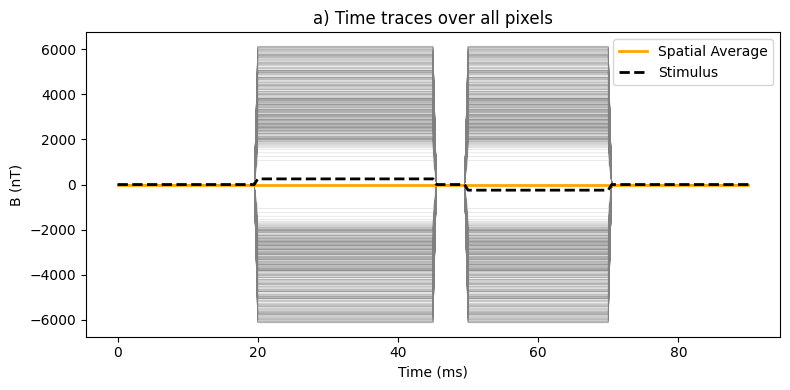

Number of pixel traces: 1681
Spatial average min [nT]: 0.0
Spatial average max [nT]: 0.0
Stimulus plotted with scale factor: 250


In [25]:
all_traces = Bcube.reshape(len(t_ms), -1)
spatial_average = np.mean(all_traces, axis=1)
stimulus_plot = 250 * stimulus

plt.figure(figsize=(8, 4))

for i in range(all_traces.shape[1]):
    plt.plot(t_ms, all_traces[:, i], color='gray', alpha=0.12, lw=0.5)

plt.plot(t_ms, spatial_average, color='orange', lw=2, label='Spatial Average')
plt.plot(t_ms, stimulus_plot, 'k--', lw=2, label='Stimulus')

plt.xlabel('Time (ms)')
plt.ylabel('B (nT)')
plt.title('a) Time traces over all pixels')
plt.legend()
plt.tight_layout()
plt.show()

print("Number of pixel traces:", all_traces.shape[1])
print("Spatial average min [nT]:", np.min(spatial_average))
print("Spatial average max [nT]:", np.max(spatial_average))
print("Stimulus plotted with scale factor:", 250)

In [26]:
xA_um, yA_um = -30, 0
xB_um, yB_um =  30, 0

ixA = np.argmin(np.abs(x_um - xA_um))
iyA = np.argmin(np.abs(y_um - yA_um))

ixB = np.argmin(np.abs(x_um - xB_um))
iyB = np.argmin(np.abs(y_um - yB_um))

print("Point A requested [um]:", (xA_um, yA_um))
print("Point A actual    [um]:", (x_um[ixA], y_um[iyA]))
print("Point B requested [um]:", (xB_um, yB_um))
print("Point B actual    [um]:", (x_um[ixB], y_um[iyB]))
print("Static signal at A [nT]:", signal_map[iyA, ixA])
print("Static signal at B [nT]:", signal_map[iyB, ixB])

Point A requested [um]: (-30, 0)
Point A actual    [um]: (np.float64(-30.0), np.float64(0.0))
Point B requested [um]: (30, 0)
Point B actual    [um]: (np.float64(30.0), np.float64(0.0))
Static signal at A [nT]: 0.0
Static signal at B [nT]: 0.0


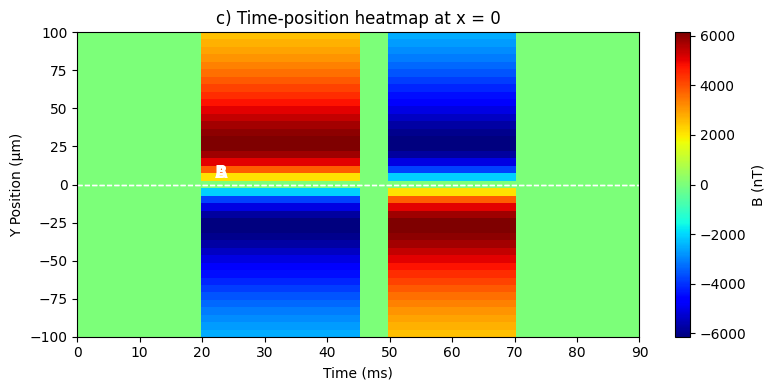

Heatmap extracted at x = 0.0 um
Heatmap shape: (181, 41)
Heatmap min [nT]: -6137.165706054618
Heatmap max [nT]: 6137.165706054618


In [28]:
ix0 = np.argmin(np.abs(x_um - 0))
heatmap = Bcube[:, :, ix0]   # shape (time, y)

plt.figure(figsize=(8, 4))
plt.imshow(
    heatmap.T,
    extent=[t_ms.min(), t_ms.max(), y_um.min(), y_um.max()],
    origin='lower',
    aspect='auto',
    cmap='jet'
)

plt.axhline(yA_um, color='white', linestyle='--', lw=1)
plt.axhline(yB_um, color='white', linestyle='--', lw=1)

plt.text(22, yA_um + 4, 'A', color='white', fontsize=12, weight='bold')
plt.text(22, yB_um + 4, 'B', color='white', fontsize=12, weight='bold')

plt.xlabel('Time (ms)')
plt.ylabel('Y Position (µm)')
plt.title('c) Time-position heatmap at x = 0')
plt.colorbar(label='B (nT)')
plt.tight_layout()
plt.show()

print("Heatmap extracted at x =", x_um[ix0], "um")
print("Heatmap shape:", heatmap.shape)
print("Heatmap min [nT]:", np.min(heatmap))
print("Heatmap max [nT]:", np.max(heatmap))